### Make a weather forcast agent using public Weather APIs such as Open-Meteo 

### Tasks

- get the city name from user
- create the URL 
- Get the tempreture or other weather info
- parse the Json file and extract important features only.



####  First project creating URL and use GET method

In [40]:
import requests

city = input("Please Enter city name: ")


# Step 1: Get coordinates from Open-Meteo Geocoding API
geo_url = f"https://geocoding-api.open-meteo.com/v1/search?name={city}&count=1"


response = requests.get(geo_url).json()
#print(response)

# Extract latitude and logtitude
lat  = response['results'][0]['latitude']
long = response['results'][0]['longitude']


weather_url = f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={long}&current_weather=True"
response = requests.get(weather_url).json()


print("The temperature of", city," is :", response["current_weather"]["temperature"], " degree and the windspeed is ", response["current_weather"]["windspeed"]," m/s" )


The temperature of Tabriz  is : 10.2  degree and the windspeed is  24.1  m/s


#### Tasks

- Use post method with authorization
- Send the json info got from previous section to an experimental endpoint such as  https://postman-echo.com/post
- Define an API key and embed it inside the Header of message such as Authorization: Bearer YOUR_KEY

#### Second project and use POST method

In [34]:
import requests


data = {
    "city": city,
    "temperature": response["current_weather"]["temperature"],
    "windspeed": response["current_weather"]["windspeed"]
}

# ---------------------------------
# Step 2: API key
# ---------------------------------
API_KEY = "ThisIsAnAPIKey"

# ---------------------------------
# Step 3: Endpoint
# ---------------------------------
url = "https://postman-echo.com/post"

# ---------------------------------
# Step 4: Headers
# ---------------------------------
headers = {
    "Authorization": f"Bearer {API_KEY}",
}

# ---------------------------------
# Step 5: POST request
# ---------------------------------
response = requests.post(url, json=data, headers=headers)

# ---------------------------------
# Step 6: Print response
# ---------------------------------
print("Status Code:", response.status_code)


print("\n--- Sent JSON ---")
print(response.json()["json"])

print("\n--- Authorization received ---")
print(response.json()["headers"]["authorization"])

Status Code: 200

--- Sent JSON ---
{'city': 'Tabriz', 'temperature': 10.3, 'windspeed': 24.5}

--- Authorization received ---
Bearer ThisIsAnAPIKey


#### Tasks

- Get a personal URL from webhook.site
- Post same info to that URL
- Check Webhook.site to see exact info you posted 


#### Third project and send to a Webhook

In [41]:

import requests


data = {
    "city": city,
    "temperature": response["current_weather"]["temperature"],
    "windspeed": response["current_weather"]["windspeed"]
}

# ---------------------------------
# Step 2: API key
# ---------------------------------
API_KEY = "ThisIsAnAPIKey"

# ---------------------------------
# Step 3: Endpoint
# ---------------------------------
url = "https://webhook.site/97d1778a-571a-4f40-889e-9007b7dab59b"

# ---------------------------------
# Step 4: Headers
# ---------------------------------
headers = {
    "Authorization": f"Bearer {API_KEY}",
}

# ---------------------------------
# Step 5: POST request
# ---------------------------------
response = requests.post(url, json=data, headers=headers)

# ---------------------------------
# Step 6: Print response
# ---------------------------------
print("Status Code:", response.status_code)



Status Code: 200


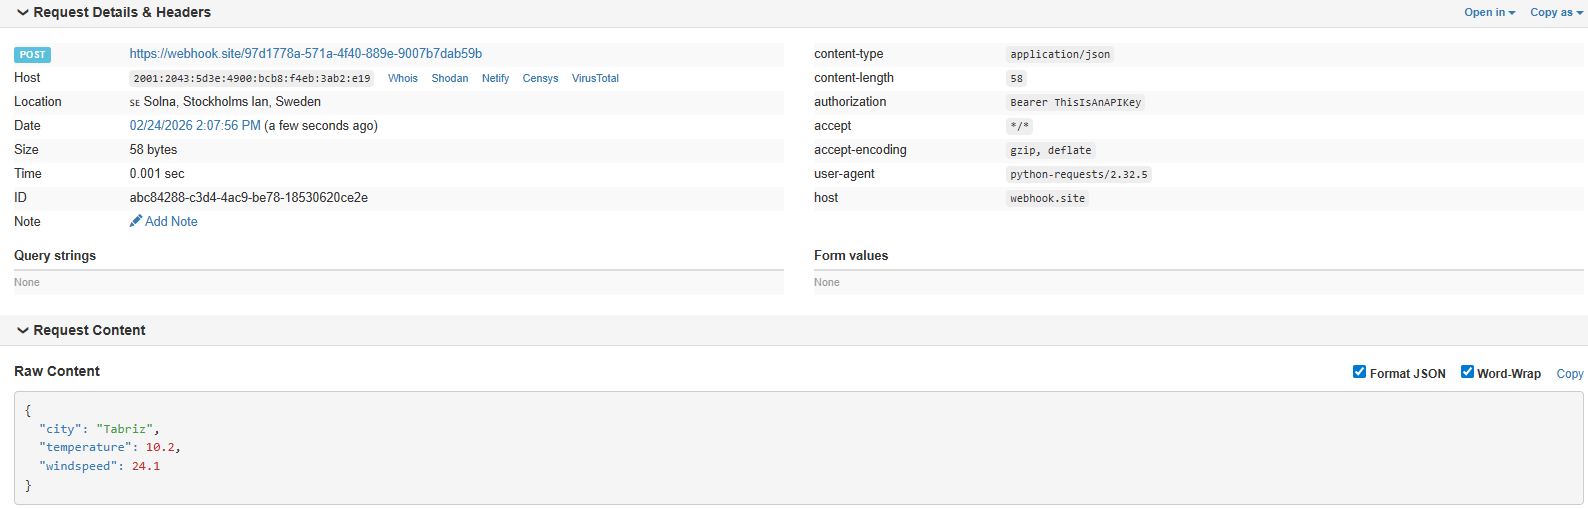